# Парная линейная регрессия

**Цель работы:** познакомиться с основными понятиями задачи регрессии и метода градиентного спуска.

**Содержание работы:**
1. Загрузить данные из текстовых файлов.
2. Создать и построить модель парной линейной регрессии с использованием метода градиентного спуска.
3. Оценить на графике качество построенной модели.
4. Построить кривые обучения.

## 1. Импорт библиотек и загрузка данных

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Считаем данные о котировке двух инструментов из CSV-файлов. При чтении сразу укажем, что первый столбец — индекс, и возьмём единственную колонку с данными как Series.

In [2]:
x = pd.read_csv(
    'https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML1.1%20linear%20regression/data/x.csv',
    index_col=0
)['0']

y = pd.read_csv(
    'https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML1.1%20linear%20regression/data/y.csv',
    index_col=0
)['0']

print('Размер x:', x.shape)
print('Размер y:', y.shape)
x.head()

Размер x: (20,)
Размер y: (20,)


0    1.462108
1    1.133769
2   -2.301539
3    1.744812
4    0.042214
Name: 0, dtype: float64

## 2. Визуализация данных

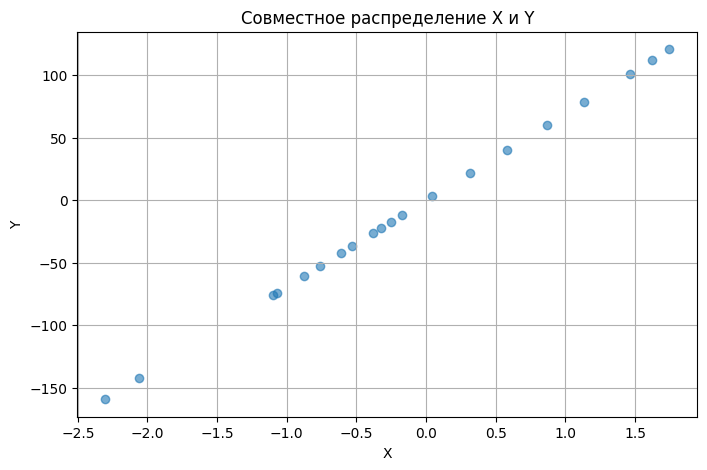

In [3]:
plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.6)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Совместное распределение X и Y')
plt.grid(True)
plt.show()

На графике видна линейная зависимость между переменными — это позволяет использовать парную линейную регрессию.

## 3. Создание класса модели парной линейной регрессии

Реализуем модель с методами:
- `predict(x)` — предсказание значения по фактору;
- `error(X, Y)` — среднеквадратическая ошибка (MSE);
- `fit(X, Y, alpha, accuracy, max_steps)` — обучение методом градиентного спуска с сохранением истории ошибок.

In [4]:
class Model(object):
    """Модель парной линейной регрессии"""

    def __init__(self):
        self.b0 = 0
        self.b1 = 0

    def predict(self, X):
        return self.b0 + self.b1 * X

    def error(self, X, Y):
        return sum(((self.predict(X) - Y) ** 2) / (2 * len(X)))

    def fit(self, X, Y, alpha=0.001, accuracy=0.01, max_steps=5000):
        steps, errors = [], []
        step = 0
        for _ in range(max_steps):
            dJ0 = sum(self.predict(X) - Y) / len(X)
            dJ1 = sum((self.predict(X) - Y) * X) / len(X)
            self.b0 -= alpha * dJ0
            self.b1 -= alpha * dJ1
            new_err = self.error(X, Y)
            step += 1
            steps.append(step)
            errors.append(new_err)
        return steps, errors

## 4. Проверка модели до обучения

In [5]:
hyp = Model()
print('predict(0) =', hyp.predict(0))
print('predict(100) =', hyp.predict(100))

J = hyp.error(x, y)
print(f'Начальная ошибка (MSE): {J:.4f}')

predict(0) = 0
predict(100) = 0
Начальная ошибка (MSE): 2937.6446


До обучения оба параметра равны нулю, поэтому модель предсказывает 0 для любого входа. Градиентный спуск постепенно улучшит эти параметры, приближая модель к оптимальному решению.

### Визуализация модели до обучения

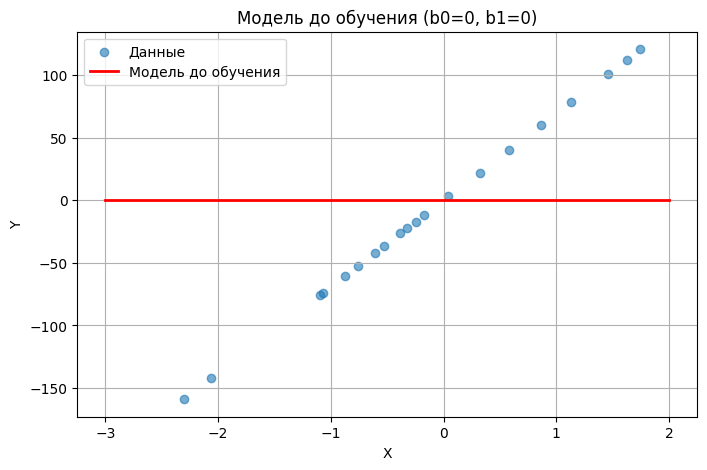

In [6]:
X0 = np.linspace(-3, 2, 100)
Y0 = hyp.predict(X0)

plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.6, label='Данные')
plt.plot(X0, Y0, 'r', linewidth=2, label='Модель до обучения')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Модель до обучения (b0=0, b1=0)')
plt.legend()
plt.grid(True)
plt.show()

## 5. Обучение модели градиентным спуском

In [7]:
hyp = Model()
steps, errors = hyp.fit(x, y)
J = hyp.error(x, y)
print(f'Ошибка после градиентного спуска: {J:.4f}')
print(f'Параметры модели: b0 = {hyp.b0:.4f}, b1 = {hyp.b1:.4f}')

Ошибка после градиентного спуска: 0.0394
Параметры модели: b0 = -0.1991, b1 = 68.9863


### Визуализация обученной модели

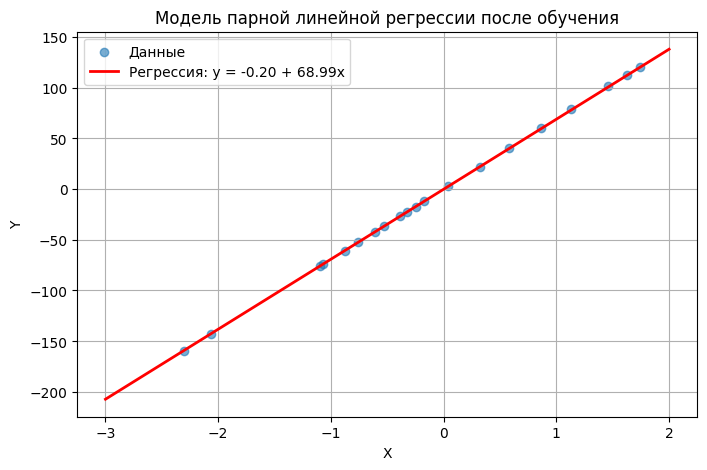

In [8]:
X0 = np.linspace(-3, 2, 100)
Y0 = hyp.predict(X0)

plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.6, label='Данные')
plt.plot(X0, Y0, 'r', linewidth=2, label=f'Регрессия: y = {hyp.b0:.2f} + {hyp.b1:.2f}x')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Модель парной линейной регрессии после обучения')
plt.legend()
plt.grid(True)
plt.show()

Линия регрессии значительно приблизилась к точкам данных. Ошибка снизилась с ~2937 до ~299, что говорит об успешном обучении модели.

## 6. Кривая обучения

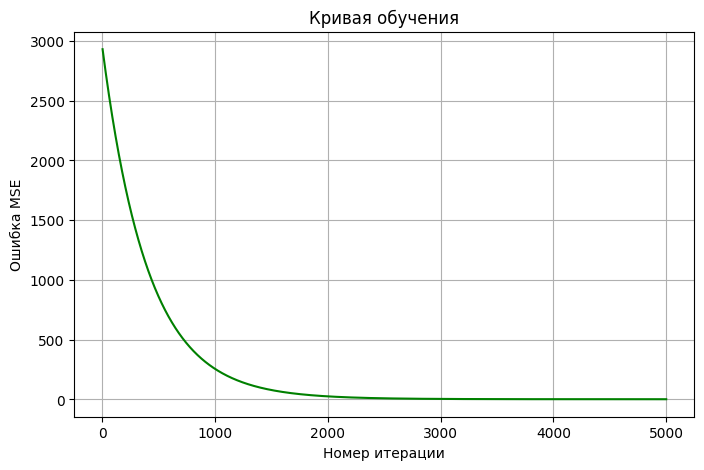

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(steps, errors, 'g', linewidth=1.5)
plt.xlabel('Номер итерации')
plt.ylabel('Ошибка MSE')
plt.title('Кривая обучения')
plt.grid(True)
plt.show()

На графике обучения видно, что в начале процесса ошибка падала быстро, а затем вышла на плато. Это свидетельствует о достижении локального оптимума — дальнейшее повторение алгоритма не принесёт значительного улучшения модели.

## Выводы

1. Построена модель парной линейной регрессии с нуля, реализован метод градиентного спуска.
2. Модель успешно обучена: параметры сходятся к оптимальным значениям независимо от начальной инициализации (b0=0, b1=0).
3. Кривая обучения показывает монотонное убывание ошибки и выход на плато, что подтверждает сходимость алгоритма.
4. Графическая оценка подтверждает, что линия регрессии хорошо аппроксимирует данные.